In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import warnings

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load data 3D
print("Memuat dataset 3D...")
X_train = np.load('../processed/train_3d_features.npy')
y_train = np.load('../processed/train_3d_labels.npy')
X_test = np.load('../processed/test_3d_features.npy')
y_test = np.load('../processed/test_3d_labels.npy')

print(f"Bentuk X_train: {X_train.shape} (Samples, TimeSteps, Features)")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test : {X_test.shape}")
print(f"Bentuk y_test : {y_test.shape}")

Memuat dataset 3D...
Bentuk X_train: (17631, 30, 17) (Samples, TimeSteps, Features)
Bentuk y_train: (17631, 1)
Bentuk X_test : (100, 30, 17)
Bentuk y_test : (100,)


### Model LSTM

In [2]:
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

model = Sequential()

model.add(LSTM(
    units=50, 
    return_sequences=True, 
    input_shape=(sequence_length, num_features)
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=50, 
    return_sequences=False
))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,851 (132.23 KB)

 Trainable params: 33,851 (132.23 KB)

 Non-trainable params: 0 (0.00 B)

None


### Training Model

In [3]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint: 
checkpoint_path = '../models/lstm_best_model.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)

# Training parameter
EPOCHS = 60
BATCH_SIZE = 200 
VALIDATION_SPLIT = 0.1

print("Mulai melatih model LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop, checkpoint],
    verbose=1 
)

Mulai melatih model LSTM...
Epoch 1/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 7493.3584
Epoch 1: val_loss improved from None to 6904.07031, saving model to ../models/lstm_best_model.h5



Epoch 1: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 6887.3657 - val_loss: 6904.0703
Epoch 2/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6054.7090
Epoch 2: val_loss improved from 6904.07031 to 6277.54443, saving model to ../models/lstm_best_model.h5



Epoch 2: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 5925.0918 - val_loss: 6277.5444
Epoch 3/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 5516.3597
Epoch 3: val_loss improved from 6277.54443 to 5744.82471, saving model to ../models/lstm_best_model.h5



Epoch 3: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 5395.2803 - val_loss: 5744.8247
Epoch 4/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4947.8720
Epoch 4: val_loss improved from 5744.82471 to 5273.76660, saving model to ../models/lstm_best_model.h5



Epoch 4: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 4932.4199 - val_loss: 5273.7666
Epoch 5/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 4598.6035
Epoch 5: val_loss improved from 5273.76660 to 4849.14502, saving model to ../models/lstm_best_model.h5


...


Epoch 53: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 289.0456 - val_loss: 289.4082
Epoch 54/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 281.8311
Epoch 54: val_loss did not improve from 289.40820
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 279.3875 - val_loss: 298.5450
Epoch 55/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 271.5464
Epoch 55: val_loss improved from 289.40820 to 278.61606, saving model to ../models/lstm_best_model.h5



Epoch 55: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 268.7313 - val_loss: 278.6161
Epoch 56/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 265.0069
Epoch 56: val_loss improved from 278.61606 to 258.12668, saving model to ../models/lstm_best_model.h5



Epoch 56: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 258.1319 - val_loss: 258.1267
Epoch 57/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 244.6913
Epoch 57: val_loss improved from 258.12668 to 211.49057, saving model to ../models/lstm_best_model.h5



Epoch 57: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 238.4789 - val_loss: 211.4906
Epoch 58/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 239.8430
Epoch 58: val_loss improved from 211.49057 to 210.59726, saving model to ../models/lstm_best_model.h5



Epoch 58: finished saving model to ../models/lstm_best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 238.2737 - val_loss: 210.5973
Epoch 59/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 234.3646
Epoch 59: val_loss did not improve from 210.59726
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 232.4784 - val_loss: 216.7371
Epoch 60/60
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 232.1229
Epoch 60: val_loss did not improve from 210.59726
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 231.8556 - val_loss: 258.1058


### Evaluasi & Plotting Loss Curve

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

=== Evaluasi LSTM (Data Uji) ===
RMSE       : 15.3120
MAE        : 11.5907
R2 Score   : 0.8642
NASA Score : 361.2199


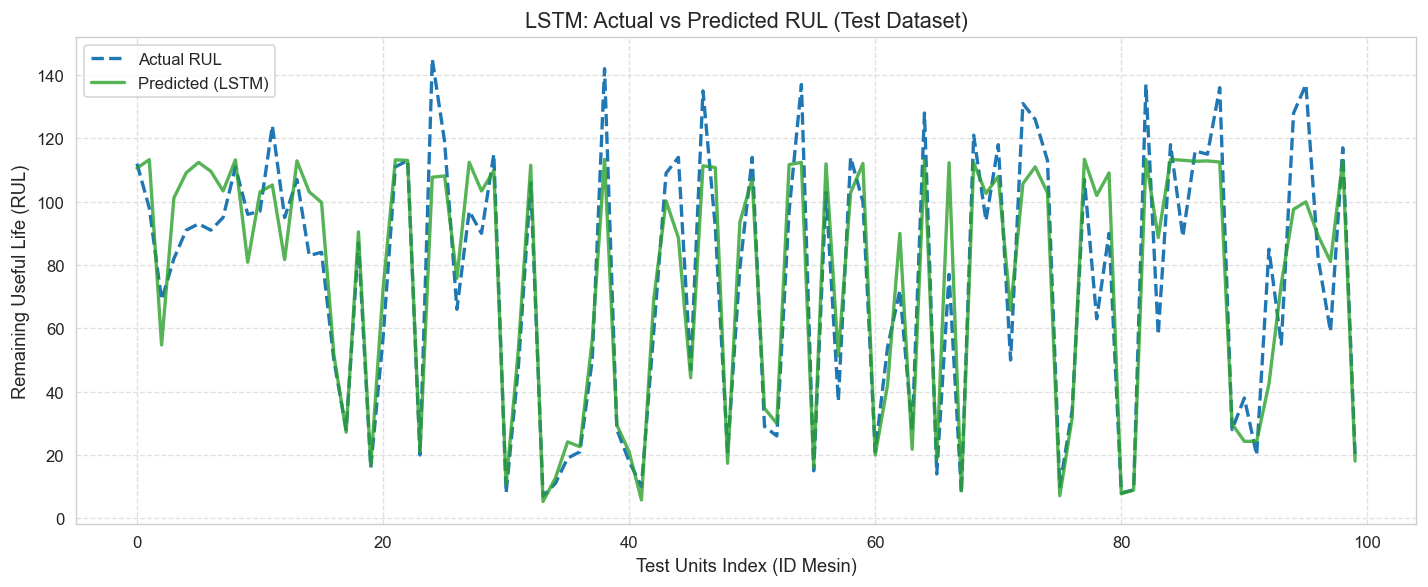

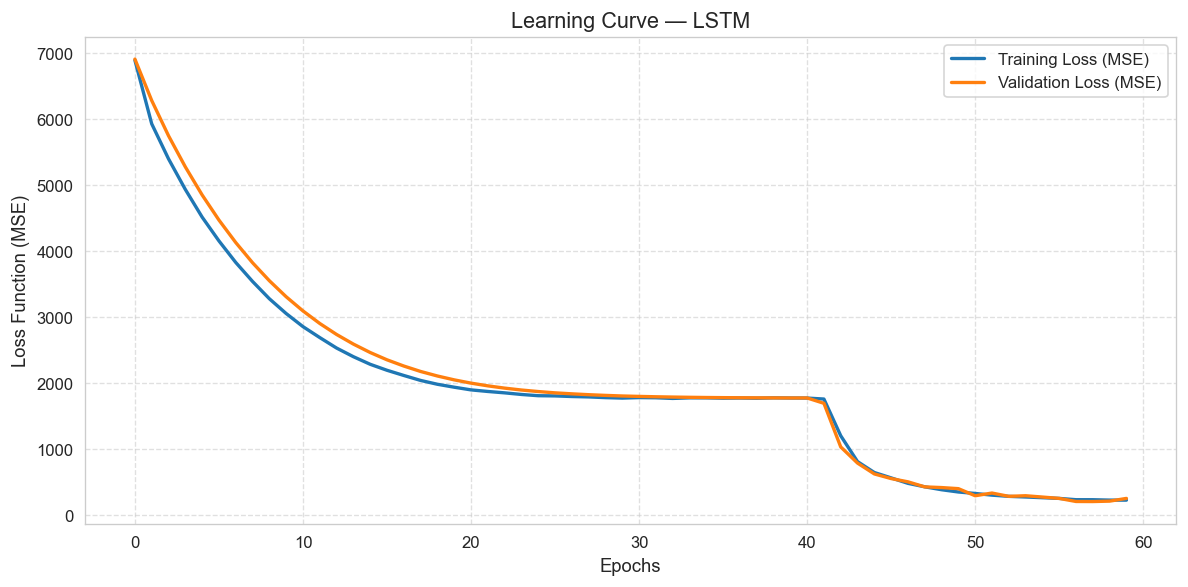

In [10]:
# ==========================================
# 4. Evaluasi & Visualisasi LSTM (Konsisten dengan XGBoost)
# ==========================================
def evaluate_model(y_true, y_pred, model_name='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    # NASA scoring function
    def nasa_score(y_true, y_pred):
        diff = y_pred - y_true
        score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
        return score
    
    ns = nasa_score(y_true, y_pred)
    
    print(f'\n=== Evaluasi {model_name} (Data Uji) ===')
    print(f'RMSE       : {rmse:.4f}')
    print(f'MAE        : {mae:.4f}')
    print(f'R2 Score   : {r2:.4f}')
    print(f'NASA Score : {ns:.4f}')
    return {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'NASA_Score': float(ns)}

# 1. Prediksi Data Test
# Keras mereturn array 2D bentuk (100, 1), kita gunakan .flatten() agar jadi (100,) seperti y_test
y_pred_lstm = model.predict(X_test).flatten()
metrics_lstm = evaluate_model(y_test, y_pred_lstm, model_name='LSTM')

# 2. Plot Prediksi vs Aktual (Gaya Line Plot persis XGBoost)
plt.figure(figsize=(12, 5))

# y_test sudah numpy array 1D
plt.plot(y_test, label='Actual RUL', linestyle='--', color='#1f77b4', linewidth=2)
# Gunakan warna hijau untuk membedakan LSTM dari XGBoost (oranye)
plt.plot(y_pred_lstm, label='Predicted (LSTM)', color='#2ca02c', alpha=0.8, linewidth=2)

plt.title('LSTM: Actual vs Predicted RUL (Test Dataset)', fontsize=13)
plt.xlabel('Test Units Index (ID Mesin)', fontsize=11)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../output/lstm_pred_vs_actual_line.png', dpi=300)
plt.show()

# 3. Plot Kurva Pembelajaran (Pengganti Feature Importance untuk LSTM)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#ff7f0e', linewidth=2)

plt.title('Learning Curve — LSTM', fontsize=13)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss Function (MSE)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../output/lstm_learning_curve.png', dpi=300)
plt.show()

# Simpan metrik ke JSON
with open('../processed/lstm_metrics.json', 'w') as f:
    json.dump(metrics_lstm, f, indent=2)